# 02 — Hazard Processing

Clean and normalize FEMA National Risk Index data into a per-tract **Hazard Exposure (H_E)** sub-index.

**Inputs:** `data/raw/nri_study_area.csv`, `data/processed/study_tracts.gpkg`  
**Outputs:** `data/processed/hazard_scores.gpkg`

**Formula:**  
`H_E = 0.40 * norm(Flood) + 0.35 * norm(Hurricane) + 0.25 * norm(Landslide)`

**Normalization:** Z-score with CDF mapping to [0, 1] — robust to outliers, mean maps to 0.5.  
**Missing data:** Median imputation (documented per tract).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.config import (
    DATA_RAW, DATA_PROCESSED,
    NRI_TRACTFIPS_COL, NRI_STCOFIPS_COL,
    NRI_SCORE_COLS, NRI_RATING_COLS, NRI_RATING_MAP, NRI_MISSING_RATINGS,
    W_HE_FLOOD, W_HE_HURRICANE, W_HE_LANDSLIDE,
)
from src.utils import load_study_tracts, z_score_normalize, impute_with_median

print("Imports OK")

Imports OK


## Load Data

In [2]:
tracts = load_study_tracts()
print(f"Tracts: {len(tracts)}")

nri = pd.read_csv(
    DATA_RAW / "nri_study_area.csv",
    dtype={NRI_TRACTFIPS_COL: str, NRI_STCOFIPS_COL: str},
)
print(f"NRI records: {len(nri)}")

# Verify GEOID alignment between tracts and NRI
tract_geoids = set(tracts["GEOID"])
nri_geoids = set(nri[NRI_TRACTFIPS_COL])
matched = tract_geoids & nri_geoids
print(f"GEOID match: {len(matched)}/{len(tract_geoids)} tracts found in NRI")

unmatched = tract_geoids - nri_geoids
if unmatched:
    print(f"  WARNING: {len(unmatched)} tracts not found in NRI: {unmatched}")

Tracts: 2660
NRI records: 2660
GEOID match: 2660/2660 tracts found in NRI


## Inspect Risk Scores and Ratings

In [3]:
score_cols = list(NRI_SCORE_COLS.keys())
rating_cols = list(NRI_RATING_COLS.keys())

print("=== Numeric Risk Scores ===")
display(nri[score_cols].describe())

print("\n=== Categorical Risk Ratings ===")
for col in rating_cols:
    print(f"\n{col} ({NRI_RATING_COLS[col]}):")
    print(nri[col].value_counts().to_string())

=== Numeric Risk Scores ===


,IFLD_RISKS,HRCN_RISKS,LNDS_RISKS
count,2660.000000,2660.000000,2660.000000
mean,55.429122,71.299203,61.176989
std,25.307656,16.645439,20.158848
min,0.000000,9.271756,0.000000
25%,35.810650,56.677562,47.097559
50%,57.716457,68.899902,61.606198
75%,76.876197,84.989807,74.556443
max,99.680116,99.995782,99.975028



=== Categorical Risk Ratings ===

IFLD_RISKR (Inland Flooding Risk Rating):
IFLD_RISKR
Relatively Moderate    1037
Relatively Low          828
Relatively High         554
Very Low                199
Very High                41
No Rating                 1

HRCN_RISKR (Hurricane Risk Rating):
HRCN_RISKR
Relatively Low         1474
Relatively Moderate     438
Very High               298
Very Low                260
Relatively High         190

LNDS_RISKR (Landslide Risk Rating):
LNDS_RISKR
Very Low               2221
Relatively Low          252
Relatively Moderate     134
Relatively High          41
No Rating                 9
Very High                 3


## Handle Missing / Insufficient Data

Some tracts may have "Insufficient Data" for certain hazards (e.g., landslide in flat areas).  
**Decision:** Fill missing risk scores with the **study area median** — assumes missing data
represents average risk rather than zero risk (more conservative than fill-with-0).

In [4]:
# Ensure NRI has GEOID column for imputation logging
nri["GEOID"] = nri[NRI_TRACTFIPS_COL]

score_cols = list(NRI_SCORE_COLS.keys())
rating_cols = list(NRI_RATING_COLS.keys())
imputation_log = {}

print("Missing values in risk score columns (before handling):")
print(nri[score_cols].isnull().sum())

# Set scores to NaN where rating indicates insufficient/missing data
for col in rating_cols:
    missing_mask = nri[col].isin(NRI_MISSING_RATINGS)
    n_missing = missing_mask.sum()
    if n_missing > 0:
        score_col = col.replace("RISKR", "RISKS")
        print(f"\n{col}: {n_missing} tracts with missing/insufficient rating -> setting {score_col} to NaN")
        nri.loc[missing_mask, score_col] = np.nan

# Impute all NaN scores with study area median (uniform strategy)
print("\nImputing missing scores with study area median:")
for col in score_cols:
    nri, imputed = impute_with_median(nri, col, label=NRI_SCORE_COLS[col])
    imputation_log[col] = imputed

print(f"\nImputation summary:")
for col, geoids in imputation_log.items():
    print(f"  {NRI_SCORE_COLS[col]}: {len(geoids)} tracts imputed")

Missing values in risk score columns (before handling):
IFLD_RISKS    0
HRCN_RISKS    0
LNDS_RISKS    0
dtype: int64

IFLD_RISKR: 1 tracts with missing/insufficient rating -> setting IFLD_RISKS to NaN

LNDS_RISKR: 9 tracts with missing/insufficient rating -> setting LNDS_RISKS to NaN

Imputing missing scores with study area median:
  Imputed 1 missing values in 'Inland Flooding Risk Score' with median=57.7634
    GEOIDs: ['37089980100']
  Imputed 9 missing values in 'Landslide Risk Score' with median=61.7590
    GEOIDs: ['37019020516', '37049960800', '37089980100', '37107010400', '37129010501', '37129011906', '37147001302', '37147001404', '37155961200']

Imputation summary:
  Inland Flooding Risk Score: 1 tracts imputed
  Hurricane Risk Score: 0 tracts imputed
  Landslide Risk Score: 9 tracts imputed


## Compute Hazard Exposure Sub-Index (H_E)

Z-score normalize each hazard risk score within the study area (mapped to [0,1] via CDF),
then combine with weights:

| Hazard | Column | Weight |
|--------|--------|--------|
| Inland Flooding | IFLD_RISKS | 0.40 |
| Hurricane | HRCN_RISKS | 0.35 |
| Landslide | LNDS_RISKS | 0.25 |

**Note:** NRI v1.20 renamed "Riverine Flooding" to "Inland Flooding" (RFLD → IFLD).  
Z-score normalization maps the study area mean to 0.5, with values spread by standard deviations.
This is more robust to outliers than min-max normalization.

In [5]:
# Z-score normalize each hazard score (mapped to [0,1] via CDF)
nri["ifld_norm"] = z_score_normalize(nri["IFLD_RISKS"])
nri["hrcn_norm"] = z_score_normalize(nri["HRCN_RISKS"])
nri["lnds_norm"] = z_score_normalize(nri["LNDS_RISKS"])

# Weighted combination
nri["H_E"] = (
    W_HE_FLOOD * nri["ifld_norm"]
    + W_HE_HURRICANE * nri["hrcn_norm"]
    + W_HE_LANDSLIDE * nri["lnds_norm"]
)

print("Hazard Exposure (H_E) distribution:")
print(nri["H_E"].describe())
print(f"\nNormalized component means (should be ~0.5):")
for col in ["ifld_norm", "hrcn_norm", "lnds_norm"]:
    print(f"  {col}: {nri[col].mean():.4f}")
print(f"\nComponent correlations with H_E:")
for col in ["ifld_norm", "hrcn_norm", "lnds_norm"]:
    print(f"  {col}: {nri[col].corr(nri['H_E']):.3f}")

Hazard Exposure (H_E) distribution:
count    2660.000000
mean        0.500465
std         0.194228
min         0.019206
25%         0.364308
50%         0.514316
75%         0.648894
max         0.915965
Name: H_E, dtype: float64

Normalized component means (should be ~0.5):
  ifld_norm: 0.5099
  hrcn_norm: 0.4896
  lnds_norm: 0.5006

Component correlations with H_E:
  ifld_norm: 0.827
  hrcn_norm: 0.517
  lnds_norm: 0.512


## Join to Tracts and Save

In [6]:
# Columns to carry forward
nri_output_cols = [
    NRI_TRACTFIPS_COL, "IFLD_RISKS", "HRCN_RISKS", "LNDS_RISKS",
    "ifld_norm", "hrcn_norm", "lnds_norm", "H_E",
]

hazard_gdf = tracts.merge(
    nri[nri_output_cols],
    left_on="GEOID",
    right_on=NRI_TRACTFIPS_COL,
    how="left",
)

# Check for unmatched tracts
n_missing = hazard_gdf["H_E"].isnull().sum()
if n_missing > 0:
    print(f"WARNING: {n_missing} tracts have no NRI match — filling H_E with study area median")
    hazard_gdf["H_E"] = hazard_gdf["H_E"].fillna(hazard_gdf["H_E"].median())

out_path = DATA_PROCESSED / "hazard_scores.gpkg"
hazard_gdf.to_file(out_path, driver="GPKG")
print(f"Saved {len(hazard_gdf)} tracts to {out_path}")
print(f"H_E range: [{hazard_gdf['H_E'].min():.4f}, {hazard_gdf['H_E'].max():.4f}]")

Saved 2660 tracts to /Volumes/T9/Projects/HABRI/data/processed/hazard_scores.gpkg
H_E range: [0.0192, 0.9160]


## Visualization

/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/opt/anaconda3/lib/python3.12/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: invalid value encountered in matmul
  current_pot = closest_dist_sq @ sample_weight


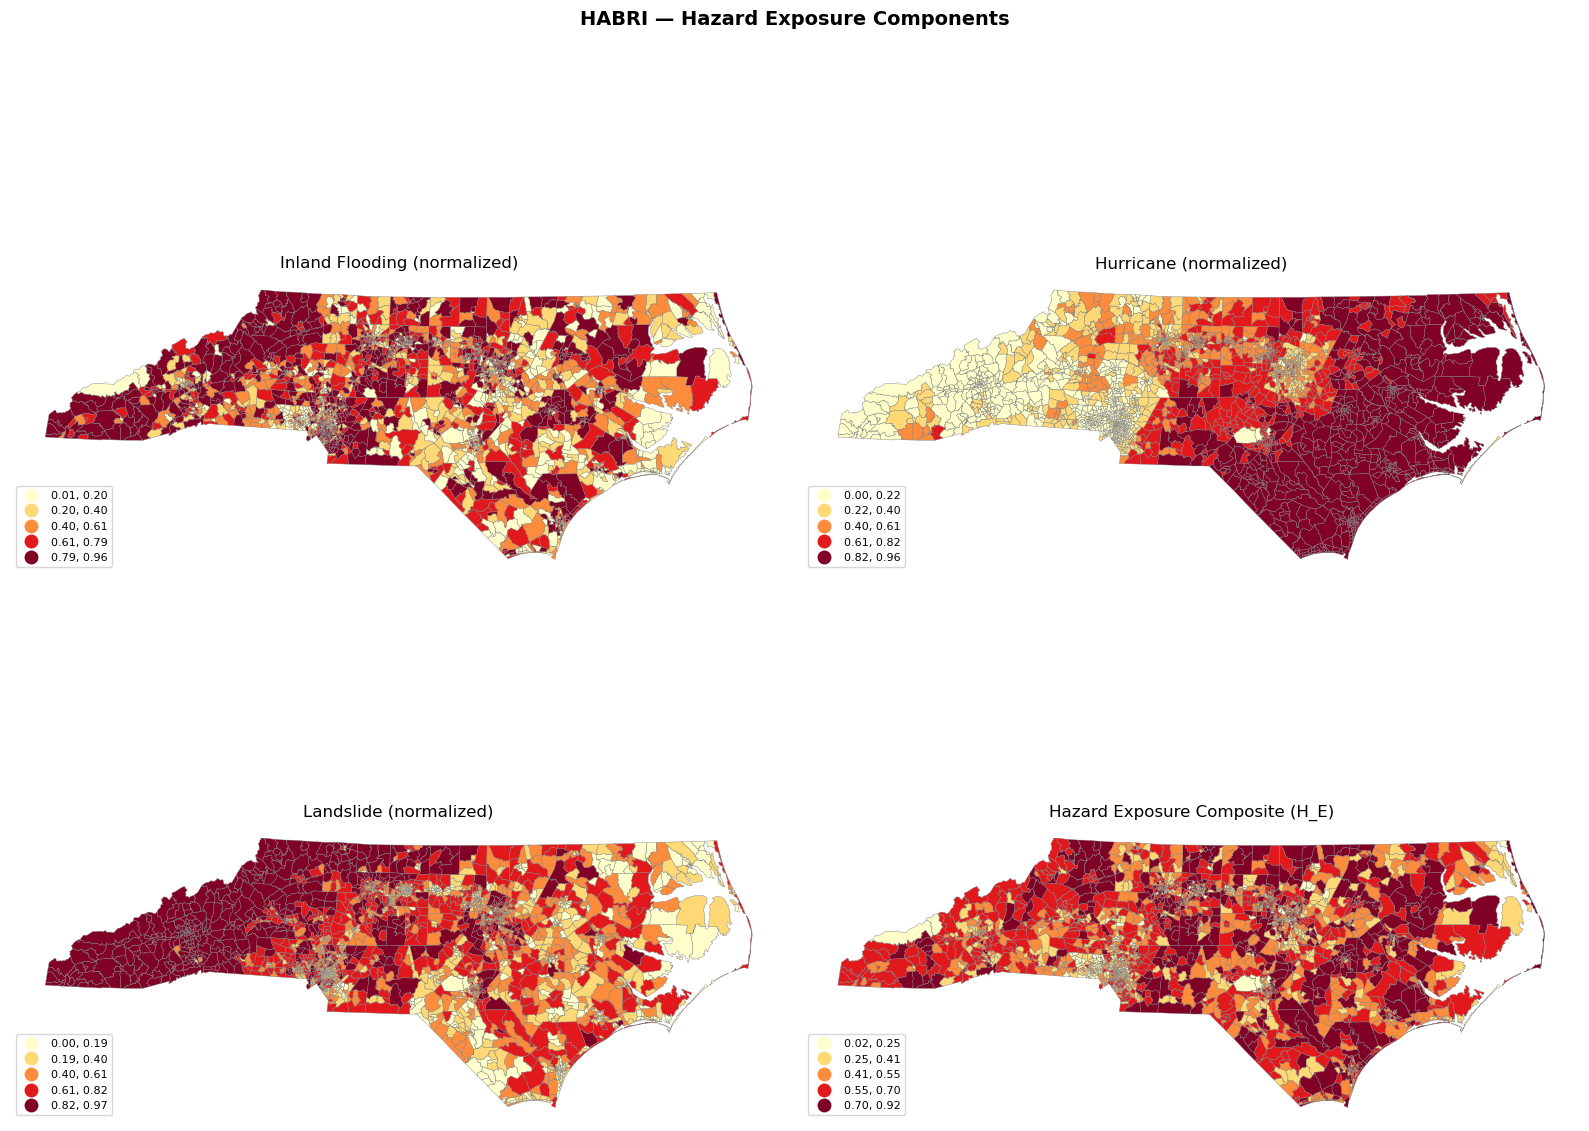

In [7]:
import mapclassify

fig, axes = plt.subplots(2, 2, figsize=(16, 14))

plot_specs = [
    ("ifld_norm", "Inland Flooding (normalized)"),
    ("hrcn_norm", "Hurricane (normalized)"),
    ("lnds_norm", "Landslide (normalized)"),
    ("H_E", "Hazard Exposure Composite (H_E)"),
]

for ax, (col, title) in zip(axes.flat, plot_specs):
    hazard_gdf.plot(
        column=col, ax=ax, legend=True, cmap="YlOrRd",
        scheme="NaturalBreaks", k=5,
        edgecolor="gray", linewidth=0.3,
        legend_kwds={"loc": "lower left", "fontsize": 8},
    )
    ax.set_title(title, fontsize=12)
    ax.set_axis_off()

plt.suptitle("HABRI — Hazard Exposure Components", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# Top 10 highest hazard-exposure tracts
top_hazard = hazard_gdf.nlargest(10, "H_E")[["GEOID", "H_E", "ifld_norm", "hrcn_norm", "lnds_norm"]]
print("Top 10 Tracts by Hazard Exposure (H_E):")
display(top_hazard)

Top 10 Tracts by Hazard Exposure (H_E):


,GEOID,H_E,ifld_norm,hrcn_norm,lnds_norm
1584,37123960302,0.915965,0.944977,0.863042,0.943640
842,37191000603,0.910829,0.932891,0.949264,0.821723
2203,37151030700,0.906338,0.927415,0.849341,0.952409
144,37117970100,0.904180,0.934532,0.945696,0.797495
510,37091950102,0.897991,0.938042,0.949466,0.761842
2594,37051003800,0.894132,0.934891,0.894134,0.828913
1076,37063002100,0.894036,0.927369,0.830164,0.930122
1680,37055970101,0.893835,0.933506,0.957607,0.741078
2585,37191001000,0.893395,0.921306,0.950520,0.768762
1049,37129012300,0.892177,0.951484,0.957515,0.705811
